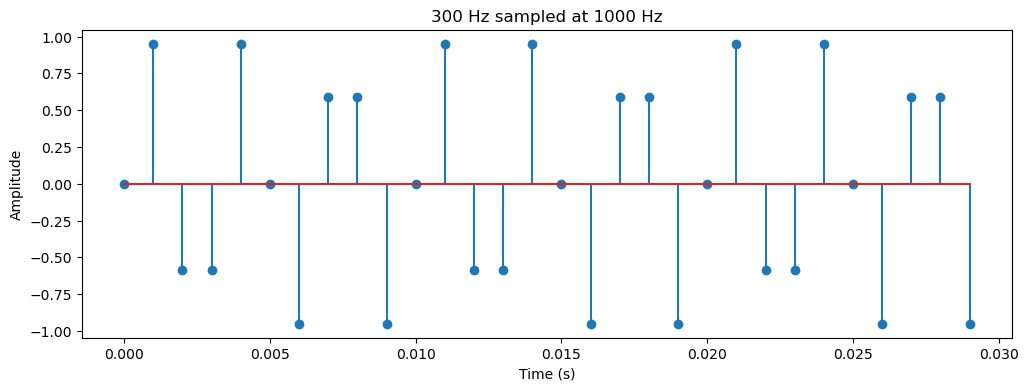

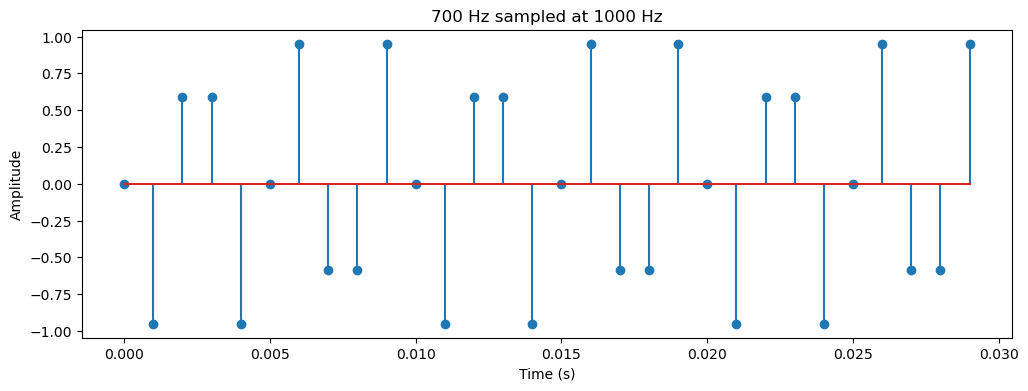

In [2]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 1000
duration = 0.03

N = int(sample_rate * duration)

time = np.arange(N) / sample_rate

# One valid frequency
freq_1 = 300

# One frequency above Nyquist
freq_2 = 700

signal_300 = np.sin(np.pi * 2 * 300 * time)

signal_700 = np.sin(np.pi * 2 * 700 * time)

plt.figure(figsize = (12,4))

plt.stem(time, signal_300)

plt.title("300 Hz sampled at 1000 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

plt.figure(figsize=(12, 4))

plt.stem(
    time,
    signal_700
)

plt.title("700 Hz sampled at 1000 Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [4]:
spectrum = np.fft.rfft(
    signal_700
)

frequencies = np.fft.rfftfreq(
    N,
    d=1 / sample_rate
)

magnitude = np.abs(spectrum)

peak_index = np.argmax(magnitude)

print(
    "Observed frequency:",
    frequencies[peak_index]
)

Observed frequency: 300.0


In [ ]:
"""
Aliasing

Aliasing happens when a continuous-time signal is sampled too slowly to represent
its frequency correctly.

The result is that a high-frequency component can appear as a completely different
lower-frequency component after sampling.

1. Nyquist frequency

If the sampling rate is:

    fs samples/second

then the highest frequency that can be represented correctly is:

    fs / 2

This is called the Nyquist frequency.

Example:

    fs = 1000 Hz

Then:

    Nyquist frequency = 500 Hz

So frequencies below 500 Hz can be represented correctly, while frequencies above
500 Hz will alias unless they are removed before sampling.

2. Example: 200 Hz

Suppose:

    fs = 1000 Hz
    signal frequency = 200 Hz

Then the number of samples per cycle is:

    1000 / 200 = 5 samples per cycle

This frequency is below Nyquist, so it can be represented correctly.

3. Example: 700 Hz

Suppose:

    fs = 1000 Hz
    signal frequency = 700 Hz

The Nyquist frequency is only:

    500 Hz

Therefore, 700 Hz cannot be represented uniquely after sampling.

Instead, it appears as a lower-frequency alias.

For this example:

    700 - 1000 = -300 Hz

For a real-valued sampled signal, this corresponds to a 300 Hz oscillation.

Therefore:

    700 Hz -> 300 Hz alias

4. Why does this happen?

Sampling means observing the continuous waveform only at discrete moments.

If the sampling rate is too low, different continuous-time sinusoids can produce
the same or equivalent sequence of sampled values.

Therefore, after sampling, the system cannot determine which original analog
frequency produced those samples.

A useful analogy is the wagon-wheel effect.

A wheel rotating very quickly can appear to:

    - rotate slowly
    - stop
    - rotate backward

when it is observed only at discrete video frames.

Audio aliasing follows the same principle.

5. Aliasing formula

A useful way to think about the aliased frequency is:

    f_alias = |f - k * fs|

where k is an integer chosen such that the resulting frequency falls inside:

    0 <= f_alias <= fs / 2

Example:

    f = 1300 Hz
    fs = 1000 Hz

Then:

    1300 - 1000 = 300 Hz

so:

    1300 Hz -> 300 Hz alias

6. Why the FFT cannot fix aliasing

Aliasing occurs during the sampling process.

Once a 700 Hz analog signal has been sampled at 1000 Hz, the resulting digital
samples already behave like the aliased lower-frequency signal.

The FFT only analyzes the digital samples it receives.

It has no information telling it:

    "These samples originally came from a 700 Hz analog signal."

Therefore, the original frequency information has already been lost.

7. Preventing aliasing

Before sampling, frequencies above the Nyquist frequency must be removed or
strongly attenuated.

This is done using an anti-aliasing low-pass filter.

Conceptually:

    analog signal
        ->
    low-pass anti-aliasing filter
        ->
    sampling

Example:

    fs = 16000 Hz

Then:

    Nyquist frequency = 8000 Hz

So frequencies above roughly 8000 Hz must be attenuated before sampling.

8. Aliasing during resampling

Aliasing is also important when downsampling existing digital audio.

Suppose audio is originally sampled at:

    48000 Hz

and we want to convert it to:

    16000 Hz

The new Nyquist frequency is:

    8000 Hz

The original 48 kHz signal may contain frequency components above 8 kHz.

If we simply discard samples without filtering, those high-frequency components
can fold into lower frequencies and create aliases.

Proper downsampling therefore follows:

    low-pass filter
        ->
    downsample

9. Key idea

Aliasing means:

    frequency above Nyquist
        ->
    appears as an incorrect lower frequency

The most important consequence is:

    once aliasing has occurred, the original frequency information cannot be
    recovered from the sampled signal alone.
"""